In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

df = pd.read_csv('../data/raw/train.csv')
print(df.shape)
df.head(3)

(75000, 4)


,sample_id,catalog_content,image_link,price
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97


In [3]:
def parse_catalog(text):
    item_name = re.search(r'Item Name:\s*(.+?)(?:\n|$)', text)
    bullets = re.findall(r'Bullet Point \d+:\s*(.+?)(?:\n|$)', text)
    description = re.search(r'Product Description:\s*(.+?)(?:\nValue:|$)', text, re.DOTALL)
    value = re.search(r'Value:\s*([\d.]+)', text)
    unit = re.search(r'Unit:\s*(.+?)(?:\n|$)', text)

    return {
        'item_name': item_name.group(1).strip() if item_name else None,
        'bullets': bullets,
        'description': description.group(1).strip() if description else None,
        'value': float(value.group(1)) if value else None,
        'unit': unit.group(1).strip() if unit else None,
    }

parsed = df['catalog_content'].apply(parse_catalog)
parsed_df = pd.DataFrame(parsed.tolist())
print(parsed_df.isnull().sum())
parsed_df.head(3)

item_name          7
bullets            0
description    42467
value            940
unit               0
dtype: int64


,item_name,bullets,description,value,unit
0,"La Victoria Green Taco Sauce Mild, 12 Ounce (P...",[],None,72.0,Fl Oz
1,"Salerno Cookies, The Original Butter Cookies, ...",[Original Butter Cookies: Classic butter cooki...,None,32.0,Ounce
2,"Bear Creek Hearty Soup Bowl, Creamy Chicken wi...",[Loaded with hearty long grain wild rice and v...,None,11.4,Ounce


In [4]:
print("Unit value counts:")
print(parsed_df['unit'].value_counts().head(20))

Unit value counts:
unit
Ounce          40982
Count          17452
Fl Oz          11082
ounce           1960
oz               962
None             940
count            741
pound            158
fl oz            128
Oz                78
ct                46
Pound             44
lb                30
Fluid Ounce       30
FL Oz             28
OZ                24
Fl. Oz            21
gram              20
Gram              19
COUNT             16
Name: count, dtype: int64


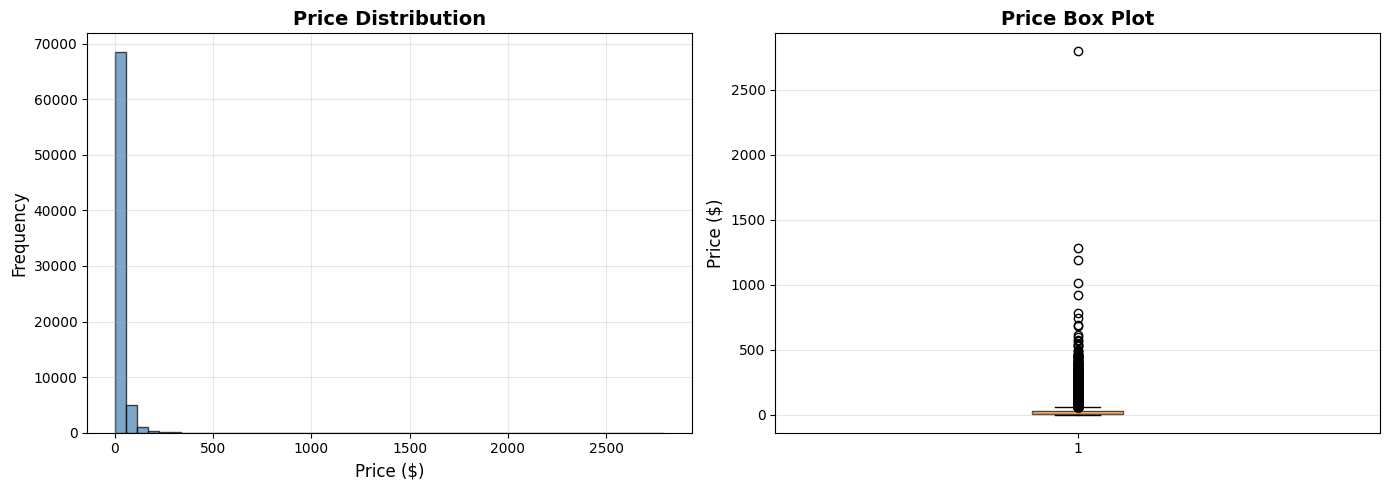

Price Range: $0.13 - $2796.00
Mean Price:  $23.65
Median Price: $14.00
Std Dev: $33.38
Products under $10: 28512 (38.0%)
Products over $100: 1893 (2.5%)


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['price'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Price Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price ($)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Boxplot
axes[1].boxplot(df['price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[1].set_title('Price Box Plot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Price ($)', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Price Range: ${df['price'].min():.2f} - ${df['price'].max():.2f}")
print(f"Mean Price:  ${df['price'].mean():.2f}")
print(f"Median Price: ${df['price'].median():.2f}")
print(f"Std Dev: ${df['price'].std():.2f}")
print(f"Products under $10: {(df['price'] < 10).sum()} ({(df['price'] < 10).mean()*100:.1f}%)")
print(f"Products over $100: {(df['price'] > 100).sum()} ({(df['price'] > 100).mean()*100:.1f}%)")

In [6]:
DIETARY_TAGS = [
    'vegan', 'gluten-free', 'gluten free', 'non-gmo', 'kosher',
    'dairy-free', 'dairy free', 'organic', 'sugar-free', 'sugar free',
    'keto', 'paleo', 'nut-free', 'nut free', 'soy-free', 'soy free'
]

def extract_tags(text):
    text_lower = text.lower()
    return [tag for tag in DIETARY_TAGS if tag in text_lower]

parsed_df['dietary_tags'] = df['catalog_content'].apply(extract_tags)
tag_counts = Counter(tag for tags in parsed_df['dietary_tags'] for tag in tags)
print(pd.Series(tag_counts).sort_values(ascending=False))

kosher         13175
organic        10431
gluten free     9922
non-gmo         9460
vegan           8418
gluten-free     6229
keto            3297
sugar free      2029
paleo           1472
dairy free      1399
sugar-free      1309
nut free        1086
dairy-free       883
soy free         713
nut-free         623
soy-free         346
dtype: int64


In [7]:
df['text_length'] = df['catalog_content'].str.len()
df['text_length'].describe()

count    75000.000000
mean       908.886547
std        852.896151
min         32.000000
25%        251.000000
50%        643.000000
75%       1280.000000
max       7894.000000
Name: text_length, dtype: float64

In [8]:
# Extract first word(s) as candidate brand from item name
def extract_brand_candidate(text):
    item_name = re.search(r'Item Name:\s*(.+?)(?:\n|$)', text)
    if not item_name:
        return None
    name = item_name.group(1).strip()
    # first word is usually the brand
    return name.split()[0] if name else None

df['brand_candidate'] = df['catalog_content'].apply(extract_brand_candidate)
print("Total unique brand candidates:", df['brand_candidate'].nunique())
print("\nTop 30 brands:")
print(df['brand_candidate'].value_counts().head(30))

Total unique brand candidates: 11260

Top 30 brands:
brand_candidate
Food          984
McCormick     621
The           619
Organic       427
Rani          425
Goya          421
Frontier      331
Betty         325
La            316
Starbucks     299
Gourmet       294
Amoretti      277
Bob's         276
Badia         276
Simply        272
Crystal       254
Fresh         249
Campbell's    242
Red           238
Blue          231
Marshalls     230
Kraft         224
Green         222
Nature's      221
Amazon        197
Generic       193
Gerber        191
Sweet         182
Eden          177
Jelly         170
Name: count, dtype: int64


## Brand Extraction Finding
First-word extraction produces 11,260 "unique brands" but ~30% are false positives 
(adjectives, articles, generic words like "Food", "The", "Organic").
Brand detection must use retail.yaml brand_aliases dictionary first,
then fuzzy match, then fall back to first meaningful word.
Estimated clean brand coverage: ~60-65% from text alone.

In [9]:
def count_bullets(text):
    return len(re.findall(r'Bullet Point \d+:', text))

def has_description(text):
    return 1 if 'Product Description:' in text else 0

df['bullet_count'] = df['catalog_content'].apply(count_bullets)
df['has_description'] = df['catalog_content'].apply(has_description)

print("Bullet point distribution:")
print(df['bullet_count'].value_counts().sort_index())
print(f"\nProducts with description: {df['has_description'].sum()} ({df['has_description'].mean()*100:.1f}%)")
print(f"Products with NO bullets and NO description: {len(df[(df['bullet_count']==0) & (df['has_description']==0)])}")

Bullet point distribution:
bullet_count
0     20524
2      1893
3      4450
4      6681
5     35931
6      3272
7      1064
8       425
9       302
10      425
11       10
12        7
13        5
14        3
15        4
16        1
17        1
21        1
26        1
Name: count, dtype: int64

Products with description: 32533 (43.4%)
Products with NO bullets and NO description: 13661


## Content Richness Tiers
- Rich (5+ bullets + description): ~32k products — high extraction confidence
- Medium (bullets, no description): ~29k products — moderate confidence  
- Bare (Item Name only): ~13.6k products (18%) — image-critical, low text signal
These tiers should map directly to confidence scoring in extraction pipeline.

In [10]:
ALLERGENS = ['milk', 'eggs', 'egg', 'wheat', 'soy', 'tree nuts', 
             'peanut', 'fish', 'shellfish', 'sesame', 'gluten']

def extract_allergens(text):
    text_lower = text.lower()
    return [a for a in ALLERGENS if a in text_lower]

df['allergens'] = df['catalog_content'].apply(extract_allergens)
allergen_counts = Counter(a for allergens in df['allergens'] for a in allergens)
print("Allergen mentions:")
print(pd.Series(allergen_counts).sort_values(ascending=False))
print(f"\nProducts with at least one allergen mention: {df['allergens'].apply(len).gt(0).sum()}")

Allergen mentions:
gluten       15505
milk          8043
egg           4052
peanut        3723
soy           3331
wheat         2953
fish          2106
eggs          1442
sesame         881
tree nuts      778
shellfish      237
dtype: int64

Products with at least one allergen mention: 28560


In [11]:
def extract_pack_size(text):
    match = re.search(r'Pack of (\d+)', text, re.IGNORECASE)
    return int(match.group(1)) if match else None

df['pack_size'] = df['catalog_content'].apply(extract_pack_size)
print("Pack size distribution:")
print(df['pack_size'].value_counts().head(15))
print(f"\nProducts with pack size: {df['pack_size'].notna().sum()} ({df['pack_size'].notna().mean()*100:.1f}%)")
print(f"Products without pack size: {df['pack_size'].isna().sum()}")

Pack size distribution:
pack_size
6.0     4304
12.0    3563
2.0     2231
1.0     2050
3.0     1955
4.0     1633
24.0     863
8.0      787
10.0     391
5.0      324
20.0     181
18.0     170
16.0     141
36.0     100
15.0      99
Name: count, dtype: int64

Products with pack size: 19707 (26.3%)
Products without pack size: 55293


## Pack Size Finding
26.3% of products have explicit pack size (Pack of N pattern).
unit_price = price / pack_size must be a derived field in ProductEntity.
Without this, price-based graph queries will return wrong results
for bulk vs single unit comparisons.

In [15]:
import yaml

with open('../src/domain_adapter/retail.yaml', 'r', encoding='utf-8') as f:
    adapter = yaml.safe_load(f)

category_keywords = adapter['category_keywords']

CATEGORY_PRIORITY = [
    "Non-Food",
    "Coffee & Tea",
    "Breakfast & Cereal",
    "Meat & Seafood",
    "Soups & Canned Goods",
    "Pasta & Noodles",
    "Bread & Bakery",
    "Protein Bars & Snacks",
    "Supplements & Health",
    "Grains, Beans & Legumes",
    "Oils & Vinegars",
    "Nuts & Seeds",
    "Personal Care & Beauty",
    "Spices & Seasonings",
    "Condiments & Sauces",
    "Baking & Cooking",
    "Snacks & Candy",
    "Beverages",
]

def detect_category(text):
    text_lower = text.lower()
    for category in CATEGORY_PRIORITY:
        keywords = category_keywords.get(category, [])
        if any(kw in text_lower for kw in keywords):
            return category
    return "Unknown"

df['detected_category'] = df['catalog_content'].apply(detect_category)
print("Category distribution:")
print(df['detected_category'].value_counts())
print(f"\nUnlabeled (Unknown): {(df['detected_category']=='Unknown').sum()} ({(df['detected_category']=='Unknown').mean()*100:.1f}%)")

Category distribution:
detected_category
Coffee & Tea               12879
Bread & Bakery              8669
Unknown                     8406
Soups & Canned Goods        6652
Snacks & Candy              5344
Condiments & Sauces         4228
Beverages                   3244
Grains, Beans & Legumes     3185
Supplements & Health        3183
Spices & Seasonings         3037
Meat & Seafood              3017
Breakfast & Cereal          2976
Baking & Cooking            2545
Pasta & Noodles             2225
Nuts & Seeds                1799
Non-Food                    1792
Oils & Vinegars              833
Protein Bars & Snacks        497
Personal Care & Beauty       489
Name: count, dtype: int64

Unlabeled (Unknown): 8406 (11.2%)


In [17]:
short_df = df[df['text_length'] < 150].copy()
print(f"Products under 150 chars: {len(short_df)}")
print("\nSample short products:")
for _, row in short_df.head(5).iterrows():
    print(f"\n--- {row['sample_id']} ---")
    print(row['catalog_content'])

Products under 150 chars: 12619

Sample short products:

--- 33127 ---
Item Name: La Victoria Green Taco Sauce Mild, 12 Ounce (Pack of 6)
Value: 72.0
Unit: Fl Oz


--- 37614 ---
Item Name: NATURES PATH CEREAL FLK MULTIGRAIN ORG ECO, 32 OZ, PK- 6
Value: 192.0
Unit: Fl Oz


--- 266475 ---
Item Name: Organic Vinegar; Apple Cider
Value: 102.0
Unit: Fl Oz


--- 88520 ---
Item Name: Himalania Pink Salt Fine Jar 10.0 OZ(Pack of 6)
Value: 10.0
Unit: Ounce


--- 81813 ---
Item Name: AMYS CHILI SPICY GF ORG, 14.7 OZ
Value: 14.7
Unit: Fl Oz



## Final EDA Summary — Key Facts for Pipeline Design

1. 75,000 products, 4 columns, zero nulls
2. 74,997 usable images (99.99%)
3. Three content tiers:
   - Rich (5+ bullets + description): ~32k products
   - Medium (bullets only): ~29k products
   - Bare (Item Name only): ~13.6k products — image critical
4. Unit normalization: 6+ variations per unit → retail.yaml handles this
5. Dietary tags: 16 canonical forms needed
6. Allergens present in 38% of products
7. Pack size in 26.3% of products — unit_price must be derived field
8. Category coverage: 88.8% labeled by keywords alone
9. 16.8% short products (<150 chars) — warehouse-style abbreviated names
10. Brand extraction unreliable from first-word alone — needs dictionary match first